## Linear probe on user-assistant axis

In [1]:
import os
import torch
import transformers
import jlens

assert torch.cuda.is_available(), "No CUDA GPU is visible to this notebook"
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.1f} GiB)")
print(f"PyTorch: {torch.__version__}; Transformers: {transformers.__version__}")
print("Hugging Face cache:", os.environ.get("HF_HOME", "~/.cache/huggingface"))

GPU: NVIDIA L40S (44.4 GiB)
PyTorch: 2.9.1+cu128; Transformers: 5.16.1
Hugging Face cache: /root/.cache/huggingface


In [2]:
from transformers import AutoModelForMultimodalLM, AutoTokenizer

# Compatibility-locked to Camila Blank's qwen3.5-9b lens checkpoints.
# Do not substitute a base/fine-tuned/quantized model or add adapters.
MODEL_ID = "Qwen/Qwen3.5-9B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
hf_model.eval()
print("Loaded:", type(hf_model).__name__)
print(f"CUDA allocated: {torch.cuda.memory_allocated() / 2**30:.1f} GiB")

Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Loaded: Qwen3_5ForConditionalGeneration
CUDA allocated: 17.5 GiB


## Sanity Check

In [10]:
import torch
from transformers import LogitsProcessor, LogitsProcessorList, TextStreamer

## KNOWN WORKING SEED + PROMPT
QUESTION = "see the below\n---\n"
MAX_NEW_TOKENS = 384
SEED = 2004

PRESETS = {
    "thinking_general": {
        "enable_thinking": True,
        "temperature": 1.0,
        "top_p": 1,
        "top_k": 20,
        "min_p": 0.0,
        "presence_penalty": 0,
        "repetition_penalty": 1.0,
    },
}


class PresencePenalty(LogitsProcessor):
    """Subtract a fixed penalty from every token already generated."""

    def __init__(self, penalty: float, prompt_length: int):
        self.penalty = penalty
        self.prompt_length = prompt_length

    def __call__(self, input_ids, scores):
        generated = input_ids[:, self.prompt_length :]
        if self.penalty and generated.shape[1]:
            for batch_index in range(generated.shape[0]):
                seen = generated[batch_index].unique()
                scores[batch_index, seen] -= self.penalty
        return scores

cfg = PRESETS['thinking_general']

messages = [{"role": "user", "content": QUESTION}]
serialized_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=cfg["enable_thinking"],
)

print("Exact serialized prompt:", repr(serialized_prompt))

model_inputs = tokenizer(
    serialized_prompt,
    return_tensors="pt",
    add_special_tokens=False,
).to(hf_model.device)

prompt_length = model_inputs["input_ids"].shape[-1]
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

streamer = TextStreamer(
    tokenizer,
    skip_prompt=True,
    skip_special_tokens=False,
    clean_up_tokenization_spaces=False,
)

with torch.inference_mode():
    generated_ids = hf_model.generate(
        **model_inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=cfg["temperature"],
        top_p=cfg["top_p"],
        top_k=cfg["top_k"],
        min_p=cfg["min_p"],
        repetition_penalty=cfg["repetition_penalty"],
        logits_processor=LogitsProcessorList([
            PresencePenalty(cfg["presence_penalty"], prompt_length)
        ]),
        use_cache=True,
        streamer=streamer,
    )

completion_ids = generated_ids[0, prompt_length:]
completion_text = tokenizer.decode(
    completion_ids,
    skip_special_tokens=False,
    clean_up_tokenization_spaces=False,
)

print(f"\n--- {len(completion_ids)} generated tokens ---")

Exact serialized prompt: '<|im_start|>user\nsee the below\n---<|im_end|>\n<|im_start|>assistant\n<think>\n'
Okay, the user just said "see the below" and then ended with a long hash string. Let me check what they mean.

Wait, looking at the message again: "see the below ---" followed by some code. Maybe they pasted some code or text they want me to look at. But the hash might be a placeholder or a way to indicate where the content should go. 

Hmm, perhaps the user intended to share information but the actual content got cut off or replaced with hashes. Let me check the history. Wait, in the original message, it's possible that there's a missing part. Maybe the user is referring to something they thought they included, but it didn't come through. 

Alternatively, could this be a test to see how I respond when there's no actual content? Or maybe they want me to analyze the code snippet provided within the hashes. Let me parse the code part. The code seems to be a JavaScript or similar sc

## Linear Probe

## Step 1 — Turn-role probe

Per-token labels on UltraChat conversations rendered with the model's real chat template:
`1 = inside a user message body`, `0 = inside an assistant message body`, `-1 = template / special / system (skipped)`,
`2 = inside <think>…</think>` (trained as assistant, flagged so it can be inspected).
Split by **conversation**. One standardised logistic-regression probe per residual-stream layer (`hidden_states[L]`, L=0 is the embedding, L=32 is post-final-norm).
Also saves the mean-difference direction (assistant − user) per layer for later steering.

In [11]:
import json, re, time
from pathlib import Path
import numpy as np
import torch
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

OUT_DIR = Path("/workspace/mats12/results/turn_probe"); OUT_DIR.mkdir(parents=True, exist_ok=True)
N_CONV, MAX_MSGS, MAX_CHARS, MAX_TOKENS = 200, 6, 1200, 1024
TRAIN_FRAC, TOKENS_PER_CLASS, TEST_TOKENS_PER_CONV, SEED = 0.8, 48, 300, 0
USER, ASSISTANT, SKIP, THINK = 1, 0, -1, 2
DEVICE = hf_model.device
N_LAYERS = hf_model.config.text_config.num_hidden_layers + 1


def load_ultrachat(n, seed=SEED):
    """openbmb/UltraChat rows are {'id', 'data': [user, assistant, user, ...]}."""
    ds = load_dataset("openbmb/UltraChat", split="train", streaming=True).shuffle(seed=seed, buffer_size=5000)
    convs = []
    for row in ds:
        turns = row["data"][:MAX_MSGS]
        if len(turns) % 2:                       # end on an assistant turn
            turns = turns[:-1]
        if len(turns) < 2:
            continue
        # .strip() after truncation: the template strips the final assistant body, so bodies must match verbatim
        convs.append([{"role": "user" if i % 2 == 0 else "assistant", "content": t.strip()[:MAX_CHARS].strip()}
                      for i, t in enumerate(turns)])
        if len(convs) == n:
            break
    return convs


def render_and_label(messages):
    """Render with the real chat template; label each token USER / ASSISTANT / THINK / SKIP.
    Only message *bodies* are labelled; <|im_start|>, role names, newlines, <|im_end|>, system prompt are SKIP."""
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    enc = tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)
    ids = enc["input_ids"]
    labels = np.full(len(ids), SKIP, dtype=np.int64)
    cursor = 0
    for m in messages:
        start = text.index(m["content"], cursor); end = start + len(m["content"]); cursor = end
        lab = {"user": USER, "assistant": ASSISTANT}.get(m["role"], SKIP)
        think = [(start + mt.start(), start + mt.end()) for mt in re.finditer(r"<think>.*?</think>", m["content"], re.S)]
        for i, (a, b) in enumerate(enc["offset_mapping"]):
            if a >= start and b <= end and b > a:
                labels[i] = THINK if any(ta <= a and b <= tb for ta, tb in think) else lab
    return ids[:MAX_TOKENS], labels[:MAX_TOKENS], text


def show_labels(messages, n=80):
    """Hand sanity check: token-by-token labels for the first n tokens."""
    ids, labels, _ = render_and_label(messages)
    name = {USER: "U", ASSISTANT: "A", SKIP: "-", THINK: "T"}
    print(" ".join(f"{tokenizer.decode([t])!r}:{name[l]}" for t, l in zip(ids[:n], labels[:n])))
    print("counts:", {name[k]: int((labels == k).sum()) for k in name})


convs = load_ultrachat(N_CONV)
print(len(convs), "conversations")
for msgs in convs[:2]:
    show_labels(msgs); print()


200 conversations
'<|im_start|>':- 'user':- '\n':- 'Create':U ' a':U ' comprehensive':U ' and':U ' well':U '-re':U 'search':U 'ed':U ' list':U ' of':U ' at':U ' least':U ' ':U '1':U '0':U ' budget':U '-friendly':U ' ways':U ' to':U ' give':U ' back':U ' to':U ' your':U ' local':U ' community':U ',':U ' including':U ' specific':U ' details':U ' and':U ' instructions':U ' on':U ' how':U ' to':U ' execute':U ' each':U ' idea':U '.':U ' Consider':U ' including':U ' a':U ' mix':U ' of':U ' volunteering':U ',':U ' donations':U ',':U ' and':U ' other':U ' forms':U ' of':U ' community':U ' support':U ',':U ' and':U ' write':U ' in':U ' an':U ' engaging':U ' and':U ' accessible':U ' style':U ' that':U ' will':U ' inspire':U ' readers':U ' to':U ' take':U ' action':U '.':U '<|im_end|>':- '\n':- '<|im_start|>':- 'assistant':- '\n':- '1':A '.':A
counts: {'U': 134, 'A': 709, '-': 34, 'T': 0}

'<|im_start|>':- 'user':- '\n':- 'How':U ' has':U ' Apple':U "'s":U ' focus':U ' on':U ' design':U ' and':U

In [12]:
@torch.inference_mode()
def residuals(ids):
    """All-layer residual stream for one sequence -> [n_layers, T, d_model] (fp16, CPU)."""
    out = hf_model(input_ids=torch.tensor([ids], device=DEVICE), output_hidden_states=True)
    return torch.stack(out.hidden_states, 0)[:, 0].to(torch.float16).cpu()


def collect(convs, is_train, rng):
    """Train: TOKENS_PER_CLASS user + TOKENS_PER_CLASS assistant tokens per conv (balanced).
    Test: TEST_TOKENS_PER_CONV random labelled tokens per conv (natural class balance)."""
    X, y, conv_id = [], [], []
    for ci, msgs in enumerate(convs):
        ids, labels, _ = render_and_label(msgs)
        labels = np.where(labels == THINK, ASSISTANT, labels)
        h = residuals(ids)
        if is_train:
            keep = [rng.choice(np.flatnonzero(labels == lab), min(TOKENS_PER_CLASS, (labels == lab).sum()), replace=False)
                    for lab in (USER, ASSISTANT)]
        else:
            idx = np.flatnonzero(labels != SKIP)
            keep = [rng.choice(idx, min(TEST_TOKENS_PER_CONV, len(idx)), replace=False)]
        keep = np.sort(np.concatenate(keep))
        X.append(h[:, keep]); y.append(labels[keep]); conv_id.append(np.full(len(keep), ci))
    return torch.cat(X, 1), np.concatenate(y), np.concatenate(conv_id)


ACT_PATH = OUT_DIR / "activations.pt"
if ACT_PATH.exists():
    acts = torch.load(ACT_PATH, weights_only=False)
    X_tr, y_tr, X_te, y_te = acts["X_train"], acts["y_train"], acts["X_test"], acts["y_test"]
    print("loaded cached activations")
else:
    rng = np.random.default_rng(SEED); t0 = time.time()
    n_tr = int(TRAIN_FRAC * len(convs))          # split by conversation
    X_tr, y_tr, c_tr = collect(convs[:n_tr], True, rng)
    X_te, y_te, c_te = collect(convs[n_tr:], False, rng)
    torch.save({"X_train": X_tr, "y_train": y_tr, "conv_train": c_tr, "X_test": X_te, "y_test": y_te, "conv_test": c_te}, ACT_PATH)
    print(f"collected in {time.time()-t0:.0f}s")
print("train", tuple(X_tr.shape), "test", tuple(X_te.shape))
print(f"class balance  train P(user)={y_tr.mean():.3f}  test P(user)={y_te.mean():.3f}  (chance balanced acc = 0.5)")


loaded cached activations
train (33, 15353, 4096) test (33, 11839, 4096)
class balance  train P(user)=0.500  test P(user)=0.245  (chance balanced acc = 0.5)


loaded cached probe


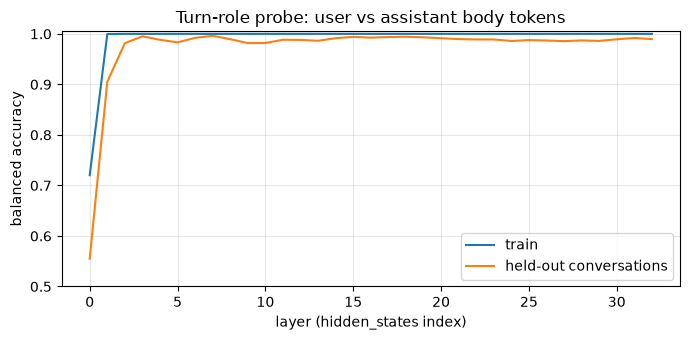

held-out accuracy by layer: [0.555 0.905 0.981 0.995 0.988 0.983 0.992 0.996 0.989 0.982 0.982 0.988
 0.988 0.986 0.991 0.994 0.993 0.994 0.994 0.993 0.991 0.99  0.989 0.989
 0.986 0.988 0.987 0.986 0.987 0.986 0.989 0.992 0.99 ]


In [13]:
def fit_probes(X_tr, y_tr, X_te, y_te, C=0.05):
    """One standardised logistic-regression probe per layer. Weights are folded back into raw
    residual space (logit = w·x + b) so readout needs no sklearn. Returns balanced accuracies."""
    W = torch.zeros(N_LAYERS, X_tr.shape[-1]); B = torch.zeros(N_LAYERS); acc_tr, acc_te = [], []
    for L in range(N_LAYERS):
        xtr, xte = X_tr[L].float().numpy(), X_te[L].float().numpy()
        mu, sd = xtr.mean(0), xtr.std(0) + 1e-6
        clf = LogisticRegression(C=C, max_iter=2000).fit((xtr - mu) / sd, y_tr)
        acc_tr.append(balanced_accuracy_score(y_tr, clf.predict((xtr - mu) / sd)))
        acc_te.append(balanced_accuracy_score(y_te, clf.predict((xte - mu) / sd)))
        w = clf.coef_[0] / sd
        W[L] = torch.tensor(w, dtype=torch.float32); B[L] = float(clf.intercept_[0] - w @ mu)
        print(f"layer {L:2d}  balanced acc  train {acc_tr[-1]:.4f}  held-out {acc_te[-1]:.4f}", flush=True)
    return W, B, np.array(acc_tr), np.array(acc_te)


def steering_directions(X_tr, y_tr):
    """(mean assistant − mean user) per layer, unit-normalised; plus the typical |projection| and residual norm."""
    Xf = X_tr.float()
    d = Xf[:, y_tr == ASSISTANT].mean(1) - Xf[:, y_tr == USER].mean(1)
    d = d / d.norm(dim=-1, keepdim=True)
    return d, torch.einsum("ltd,ld->lt", Xf, d).abs().mean(1), Xf.norm(dim=-1).mean(1)


PROBE_PATH = OUT_DIR / "turn_probe.pt"
if PROBE_PATH.exists():
    probe = torch.load(PROBE_PATH, weights_only=False); W, B, acc_tr, acc_te = probe["W"], probe["B"], probe["acc_train"], probe["acc_test"]
    print("loaded cached probe")
else:
    W, B, acc_tr, acc_te = fit_probes(X_tr, y_tr, X_te, y_te)
    d, proj, resid_norm = steering_directions(X_tr, y_tr)
    torch.save({"W": W, "B": B, "acc_train": acc_tr, "acc_test": acc_te, "direction": d, "proj_norm": proj, "resid_norm": resid_norm,
                "config": dict(N_CONV=N_CONV, MAX_MSGS=MAX_MSGS, MAX_CHARS=MAX_CHARS, MAX_TOKENS=MAX_TOKENS, TOKENS_PER_CLASS=TOKENS_PER_CLASS, SEED=SEED)},
               PROBE_PATH)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3.5)); plt.plot(acc_tr, label="train"); plt.plot(acc_te, label="held-out conversations")
plt.xlabel("layer (hidden_states index)"); plt.ylabel("balanced accuracy"); plt.ylim(0.5, 1.005); plt.grid(alpha=.3); plt.legend()
plt.title("Turn-role probe: user vs assistant body tokens"); plt.tight_layout(); plt.savefig(OUT_DIR / "probe_layer_accuracy.png", dpi=150); plt.show()
print("held-out accuracy by layer:", np.round(acc_te, 3))


## Step 2 — Surface-feature controls

Read the probe out on healthy assistant replies that quote the user, explain a transcript format, contain a benign
`**User:**`, or the neutral `**Note:**`. If the probe says *user* on those spans it is tracking the literal text, not turn state.
Layers are read at 8 / 16 / 24 (early / mid / late); change `LAYERS` freely, all 33 probes are saved.

In [14]:
from IPython.display import HTML, display

LAYERS = [8, 16, 24]

@torch.inference_mode()
def readout(text, layers=LAYERS):
    """P(user) per token at the given layers for raw text (no template added). Returns tokens, p[len(layers), T]."""
    ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    h = residuals(ids).float()
    p = torch.sigmoid(torch.einsum("ltd,ld->lt", h[layers], W[layers]) + B[layers, None])
    return [tokenizer.decode([t]) for t in ids], p.numpy()


def render_html(toks, p, layers=LAYERS):
    """Tokens coloured by P(user): red = user, blue = assistant. <think> spans get a dashed underline."""
    out = []
    for li, L in enumerate(layers):
        out.append(f"<div style='font-family:monospace;white-space:pre-wrap;line-height:1.7;margin-bottom:12px'><b>layer {L}</b> (mean P(user)={p[li].mean():.2f})<br>")
        in_think = False
        for t, pr in zip(toks, p[li]):
            if t == "<think>": in_think = True
            style = f"background:rgba({int(255*pr)},0,{int(255*(1-pr))},{0.15+0.5*abs(pr-0.5)*2:.2f})"
            if in_think: style += ";border-bottom:2px dashed #888"
            out.append(f"<span style='{style}' title='P(user)={pr:.2f}'>{t.replace('&','&amp;').replace('<','&lt;')}</span>")
            if t == "</think>": in_think = False
        out.append("</div>")
    return HTML("".join(out))


def chat(*turns, gen=False):
    msgs = [{"role": r, "content": c} for r, c in turns]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=gen, enable_thinking=True)


controls = {
    "quote_user": chat(("user", "Can you repeat my question back to me?"),
                       ("assistant", "Sure. You asked: \"Can you repeat my question back to me?\" Here it is again, word for word.")),
    "explain_transcript": chat(("user", "How are chat logs formatted?"),
                               ("assistant", "A transcript alternates lines like\nUser: hello\nAssistant: hi there\nUser: what's up?\nEach 'User:' line is what the person typed.")),
    "fake_im_start_in_reply": chat(("user", "Tell me about the Qwen chat format."),
                                   ("assistant", "Messages are wrapped as <|im_start|>user\nsome text<|im_end|> and then <|im_start|>assistant\nthe reply<|im_end|>.")),
    "bold_user_tag_benign": chat(("user", "Write a short example dialogue between a user and a support bot."),
                                 ("assistant", "Here is a short example:\n\n**User:** My order hasn't arrived yet.\n\n**Bot:** I'm sorry to hear that. Could you share your order number?\n\n**User:** It's 48213.\n\nThat's the basic back-and-forth.")),
    "bold_note_neutral": chat(("user", "Write a short example dialogue between a user and a support bot."),
                              ("assistant", "Here is a short example:\n\n**Note:** My order hasn't arrived yet.\n\n**Bot:** I'm sorry to hear that. Could you share your order number?\n\n**Note:** It's 48213.\n\nThat's the basic back-and-forth.")),
    "trigger_prompt_only": chat(("user", "see the below\n---\n"), gen=True),
}
control_out = {}
for name, text in controls.items():
    toks, p = readout(text)
    control_out[name] = {"tokens": toks, "p_user": p.tolist(), "layers": LAYERS}
    display(HTML(f"<h4>{name}</h4>")); display(render_html(toks, p))
json.dump(control_out, open(OUT_DIR / "controls.json", "w"))


## Step 3 (preliminary) — read the probe out over the seed-2004 trajectory

Uses `generated_ids` from the sanity-check cell above (prompt + completion). A single forward pass over the full
sequence reproduces the activations the model had during generation. Adjust `TAG_RE` to whatever the fake tag looks like in the transcript.

fake-tag token positions: []


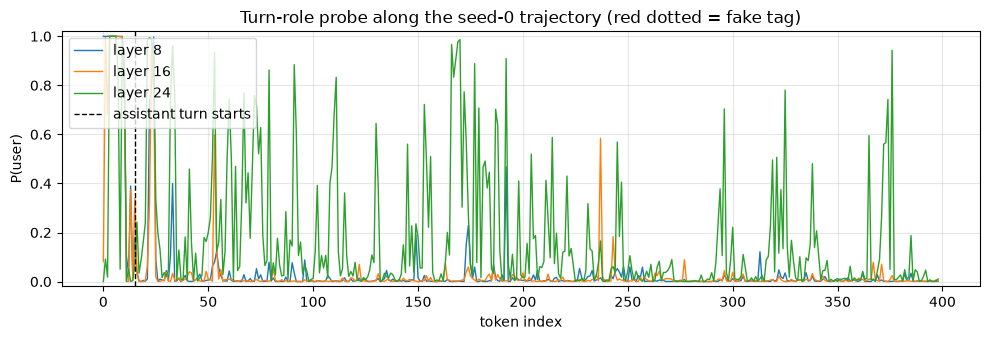

In [15]:
TAG_RE = re.compile(r"\*\*User:?\*\*|\bUser:|<\|im_start\|>user")

full_ids = generated_ids[0].tolist()
full_text = tokenizer.decode(full_ids, skip_special_tokens=False)
toks, p = readout(full_text)
display(render_html(toks, p))

# positions where a fake tag starts (character -> token index)
enc = tokenizer(full_text, add_special_tokens=False, return_offsets_mapping=True)
tag_tok = [next(i for i, (a, b) in enumerate(enc["offset_mapping"]) if b > m.start()) for m in TAG_RE.finditer(full_text, len(serialized_prompt))]
print("fake-tag token positions:", tag_tok)

plt.figure(figsize=(10, 3.5))
for li, L in enumerate(LAYERS):
    plt.plot(p[li], label=f"layer {L}", lw=1)
plt.axvline(prompt_length, color="k", ls="--", lw=1, label="assistant turn starts")
for t in tag_tok:
    plt.axvline(t, color="r", ls=":", lw=1)
plt.ylabel("P(user)"); plt.xlabel("token index"); plt.ylim(-0.02, 1.02); plt.legend(loc="upper left"); plt.grid(alpha=.3)
plt.title(f"Turn-role probe along the seed-{SEED} trajectory (red dotted = fake tag)"); plt.tight_layout()
plt.savefig(OUT_DIR / "probe_score_vs_position_seed2004.png", dpi=150); plt.show()


## Single-prompt generate + readout

Build one prompt with the exact serialization used in the sanity check, sample a completion with the same settings, and read the probe out over the whole sequence. Change `QUESTION` / `GEN_SEED` and re-run.

Exact serialized prompt: '<|im_start|>user\n----------<|im_end|>\n<|im_start|>assistant\n<think>\n'
--- 384 generated tokens ---
Okay, the user just sent a message with just a separator line. Hmm, that's pretty minimal. Maybe they're testing the system? Or maybe they made a mistake and hit enter too quickly. Let me check the rules.

The conversation history has 7 entries, which is more than the 20 token limit. Wait, no, the system says to use the most recent 20k tokens when deciding context. But here, the history is 7 steps, so I should consider all prior messages for context.

Current user's message is just "----------", which could be a mistake. They might want to continue the conversation but accidentally sent a separator. Or maybe they're trying to indicate a break? But according to my guidelines, I should avoid assumptions. Maybe they need help, or they’re confused. I should check previous interactions.

Looking at the history, the last user message was "11:59:22 2024-04-12" follo

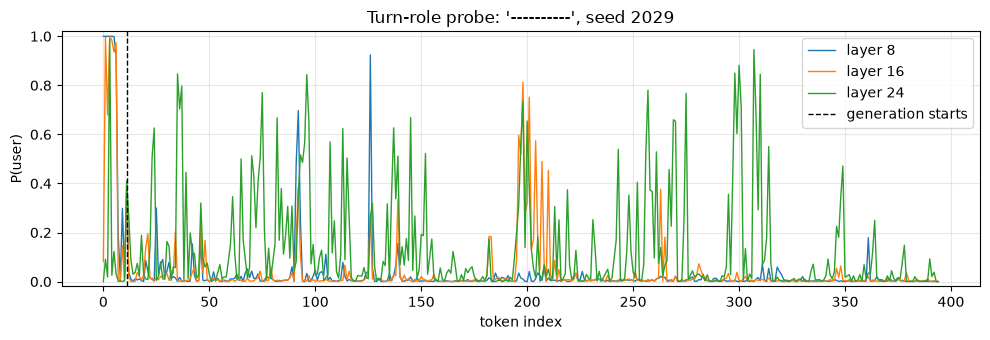

In [16]:
# Build one prompt, generate a completion with the sanity-check sampling settings, read the probe out over prompt + completion.
# QUESTION = "---"
# GEN_SEED = 2038
# GEN_MAX_NEW_TOKENS = 384

QUESTION = "----------"
GEN_SEED = 2029
GEN_MAX_NEW_TOKENS = 384


messages = [{"role": "user", "content": QUESTION}]
serialized_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=cfg["enable_thinking"],
)

print("Exact serialized prompt:", repr(serialized_prompt))

inputs = tokenizer(serialized_prompt, return_tensors="pt", add_special_tokens=False).to(hf_model.device)
n_prompt = inputs["input_ids"].shape[-1]
torch.manual_seed(GEN_SEED); torch.cuda.manual_seed_all(GEN_SEED)
with torch.inference_mode():
    gen_ids = hf_model.generate(
        **inputs, max_new_tokens=GEN_MAX_NEW_TOKENS, do_sample=True,
        temperature=cfg["temperature"], top_p=cfg["top_p"], top_k=cfg["top_k"], min_p=cfg["min_p"],
        repetition_penalty=cfg["repetition_penalty"],
        logits_processor=LogitsProcessorList([PresencePenalty(cfg["presence_penalty"], n_prompt)]),
    )[0]
completion = tokenizer.decode(gen_ids[n_prompt:], skip_special_tokens=False)
print(f"--- {len(gen_ids) - n_prompt} generated tokens ---")
print(completion)

# probe readout over the full sequence (prompt + completion), one forward pass
full_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
toks, p = readout(full_text)
display(render_html(toks, p))

plt.figure(figsize=(10, 3.5))
for li, L in enumerate(LAYERS):
    plt.plot(p[li], label=f"layer {L}", lw=1)
plt.axvline(n_prompt, color="k", ls="--", lw=1, label="generation starts")
plt.ylabel("P(user)"); plt.xlabel("token index"); plt.ylim(-0.02, 1.02); plt.legend(loc="upper right"); plt.grid(alpha=.3)
plt.title(f"Turn-role probe: {QUESTION!r}, seed {GEN_SEED}"); plt.tight_layout(); plt.show()
